# MTH793P: Advanced Machine Learning, Semester B, 2025/2026
## Final Examination

---

**Full Name:**

Danyil Shuba

**Student ID:**

12345678 (example of student id)

---

### General instructions

First, enter your **Full Name** and **Student ID** in the fields above.

**Read the following information carefully before turning to the actual exercises.**

This final project assignment is scored on a scale of 100 marks and will contribute **60% of your final mark** for this module.

This project is due by **Friday, 22 May 2026, 17:00 GMT**.

Submissions received after this deadline will be treated in accordance with the College Regulations for late submissions: Up to seven days after the deadline, late submissions will incur a penalty of 5 marks per 24 hours. Any submission received more than 168 hours (7 days) after the deadline will receive 0 marks.

The lecturer will be available to answer reasonable questions about this assessment until **Friday, 15 May 2026, 17:00 GMT**. You can contact the lecturer by email ([hong.qi@qmul.ac.uk](mailto:hong.qi@qmul.ac.uk)).

You must use this Jupyter Notebook to answer all exercises. You are not allowed to remove any cells from this notebook. You can add Markdown or code cells as needed.

You must submit this Jupyter Notebook through QMPlus. Files sent by other means, including email, will not be considered.

You cannot submit any additional files apart from this Jupyter Notebook. The ZIP file you downloaded contains various auxiliary files that you will need for the exercises. The original versions of these files will be merged into your submission automatically.


For **Markdown** exercises, **replace all occurrences of** `YOUR ANSWER HERE`  **by valid Markdown** to answer the question.

For **coding** exercises,
**replace all occurrences of**
```python
### YOUR CODE HERE
raise NotImplementedError()
```
**by valid Python code** to solve the problem.
In your solution, you can **only use** built-in Python functions and **functions from modules were imported for you in this template**.
Importing other modules is not allowed and will result in withdrawal of the corresponding marks.
If your code produces an error and you cannot fix it, write a comment to show that you are aware of the problem and indicate possible causes if you can.
You can get **partial credit**, so even if you cannot solve an exercise completely, try to answer as much as you can.


Finally, before you turn this project in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart Kernel) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All (Jupyter Notebook Version 6) or Run$\rightarrow$Run All Cells (Jupyter Notebook Version 7)). Please **do not change the file name** when you upload your Notebook to QMPlus.

<div class="alert alert-block alert-warning">
    Please answer all the questions below by writing your own Python code. Using or copy-pasting pre-existing code from any source is not permitted, and will be considered as <b>plagiarism</b> and addressed according to College Regulations. You are not allowed to collaborate with other students or ask for help from any other source, including, but not limited to, online forums or ChatGPT (or any other AI agent). By submitting your Notebook via QMPlus, you confirm that you have followed these rules and that the submitted code is your own work. Upon violation, you will fail this test with zero marks.</div>

---

### Coding style

#### Comments

Comments are an essential part of programming.
Use appropriate comments to explain the reasoning behind your code.

#### Variables & Functions

Use the variable and function names specified (**<font color=red>in red</font>**) in each exercise when writing your code. If you use other names, the testing of your code might fail, resulting in a reduced mark. For any additional variables/functions you define, choose meaningful, concise names.


It is perfectly fine if you define extra auxiliary functions to carry out a task. This is to say, even if the exercise only asks you to write a function `example_function`, you are free to add other functions like `example_function_aux`, `some_other_function`, ... and use them in your implementation of `example_function`.
Choose meaningful names for all auxiliary functions, too.

---

### Assessment criteria

The first thing we will do to evaluate your submission is to clear all outputs and run the entire notebook from the beginning to the end. It is your responsibility to ensure that the code produces **no errors**. We will not try to fix any errors when assessing your work as you have several weeks to develop this project. Instead, you will receive **zero marks for any exercises where the code cell raises an error**. If you run into an error and do not know how to fix it, comment out the critical line of code and any subsequent ones that depend on it. Add a remark indicating that you are aware of the problem and potential reasons.

If you do not know how to implement a certain operation in Python,
add a comment and explain in plain English (and in sufficient detail) what you would like to do.
You may receive partial credit for expedient ideas formulated in this way.

**10 marks (10% of the project mark)** will be awarded for **coding style**. This includes the use of appropriate variable names, suitable comments to explain complex sequences of operations, and general organization.
This is to say, even if your code is fully functional and solves the exercise, you may lose marks if the reasoning is not explained properly, or the code is not well-organized.

<div class="alert alert-block alert-danger">

**Running time:** You will be asked to code and use several machine learning methods that we studied in the lectures. If not implemented correctly, or used with the wrong parameters, these can take a long time to run. When you submit your notebook, you should make sure that:
* No single box in this notebook takes **longer than 30 seconds** to run on your personal computer.
* The entire notebook runs from beginning to end in **less than 3 minutes** on your personal computer.

You should make sure that your submitted notebook follows these limitations. Failing to do so will amount to a penalty of **20 marks**. 

---

### Admitted imports

You may only use built-in Python and the packages imported in the cell below. **Do not import additional modules.**

In [1]:
import numpy as np
from numpy.linalg import svd, norm

import matplotlib.pyplot as plt

from skimage import data
from skimage import img_as_float
from skimage.color import rgb2gray

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler

from numpy.testing import assert_equal, assert_array_equal
from numpy.testing import assert_almost_equal, assert_array_almost_equal

---

# Part I - Satellite Image Segmentation Using Spectral Clustering (20 marks)

In this part we use **Spectral Clustering** to segment a satellite image of land cover into
distinct regions — forest, water, urban area, and farmland — based on pixel color similarity.

The file **`satellite.npy`** contains a small vague satellite image of shape **(H, W, 3)**, with
RGB values normalized to $[0, 1]$. Each pixel is treated as a data point with a
3-dimensional color feature vector.

For this part you may use **SpectralClustering** from `sklearn.cluster` as
well as `numpy` for the manual steps.

---

The cell below loads the image into **`satellite`** and displays it.

Image shape: (50, 70, 3)


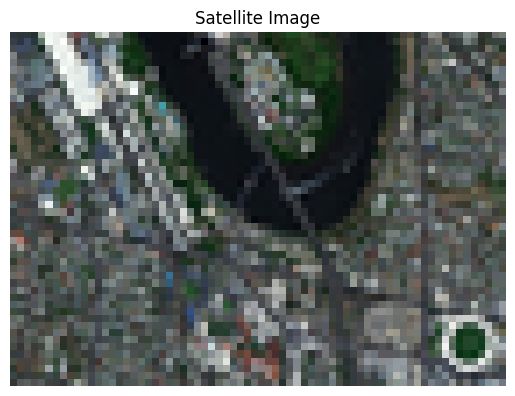

In [2]:
satellite = np.load('satellite_50x70.npy')
H, W = satellite.shape[:2]
print('Image shape:', satellite.shape)
plt.imshow(satellite); plt.axis('off'); plt.title('Satellite Image'); plt.show()

**Step 1: Prepare the pixel feature matrix.**

Reshape the satellite image into **<font color='red'>pixels</font>** — an array of shape
`(H*W, 3)` where each row is the RGB vector of one pixel. Store the image dimensions in
**<font color='red'>H</font>** and **<font color='red'>W</font>**.

In [3]:
# -1 allows the program to calculate the number of rows itself,
# while 3 says the the number of columns should remain 3
pixels = satellite.reshape((-1, 3))

# Hint: use .reshape(-1, 3) to flatten the (H, W, 3) image into a (H*W, 3) pixel matrix
# and print the resulting shape
print(pixels.shape)

(3500, 3)


In [4]:
### DO NOT REMOVE/EDIT THIS CELL ###

assert pixels.ndim == 2
assert pixels.shape[1] == 3
assert pixels.shape[0] == H * W
assert_almost_equal(pixels.min(), 0.0, decimal=3)
assert pixels.max() <= 1.0 + 1e-6
print('--- TEST PASSED ---')

--- TEST PASSED ---


**Step 2: Apply Spectral Clustering.**

Apply **SpectralClustering** to **`pixels`** with:
- `n_clusters = 3`
- `affinity = 'rbf'`
- `gamma = 50.0`
- `random_state = 0`
- `n_init = 5`

Store the integer labels (0–3) in **<font color='red'>labels_spectral</font>**, then reshape
to **(H, W)** and store in **<font color='red'>label_image</font>**.

Display `label_image` with `cmap='tab10'` alongside the original image.

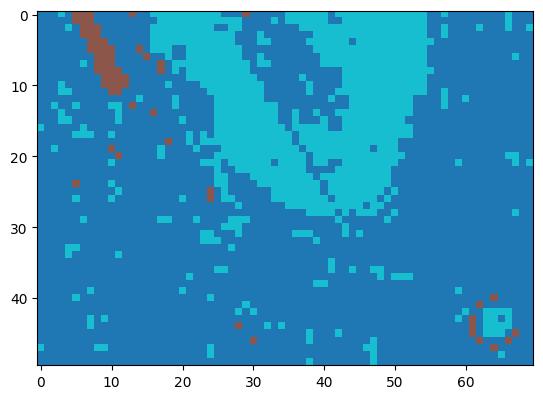

In [5]:
# setting variables from the task

# number of clusters --> we get numbers from 0 to 2 including
n_clusters = 3
# means how we want to measure the similarity between points. 
# 'rbf' means that we calculate distance between points (pixels, 3 coordinates)
# the higher affinity, the more similar the points (pixels) are 
affinity = 'rbf'
# measures how the clustering is sensitive to colours.
# similarity = exp(- gamma * (distance) ^ 2)
# distance is the Euclidean distance between pixels: sqrt((R1-R2)^2 + (G1-G2)^2 + (B1-B2)^2)
# the larger gamma, the larger sensitivity. 
# gamma = 50 means that even a small change in colours will significantly reduce the similarity
gamma = 50.0
# keep the result the same. Make the result stable,
# so after re-run of the notebook, the results will be the same
random_state = 0
# how many times we have to run the clustering.
# 5 means that we re-run the clustering 5 times
n_init = 5

# applying spectral clustering with variables set
spectral = SpectralClustering(
    n_clusters=n_clusters,
    affinity=affinity,
    gamma=gamma,
    random_state=random_state,
    n_init=n_init 
)

# this will give us integers from 0 to 2 including because of n_clusters=3,
# if we need integers from 0 to 3, we need to reset variable n_clusters = 4
labels_spectral = spectral.fit_predict(pixels)
label_image = labels_spectral.reshape((H, W))

# tab10 makes our 3 clusters appear in different clusters
plt.imshow(label_image, cmap="tab10")




In [6]:
### DO NOT REMOVE/EDIT THIS CELL ###

Now explore other parameters. Change the number of clusters n_clusters to 4, 5, and other values you want to try; do similar for other parameters in the SpectralClustering function. Show your results. Do the results look more or less reasonable as you change those parameters? 

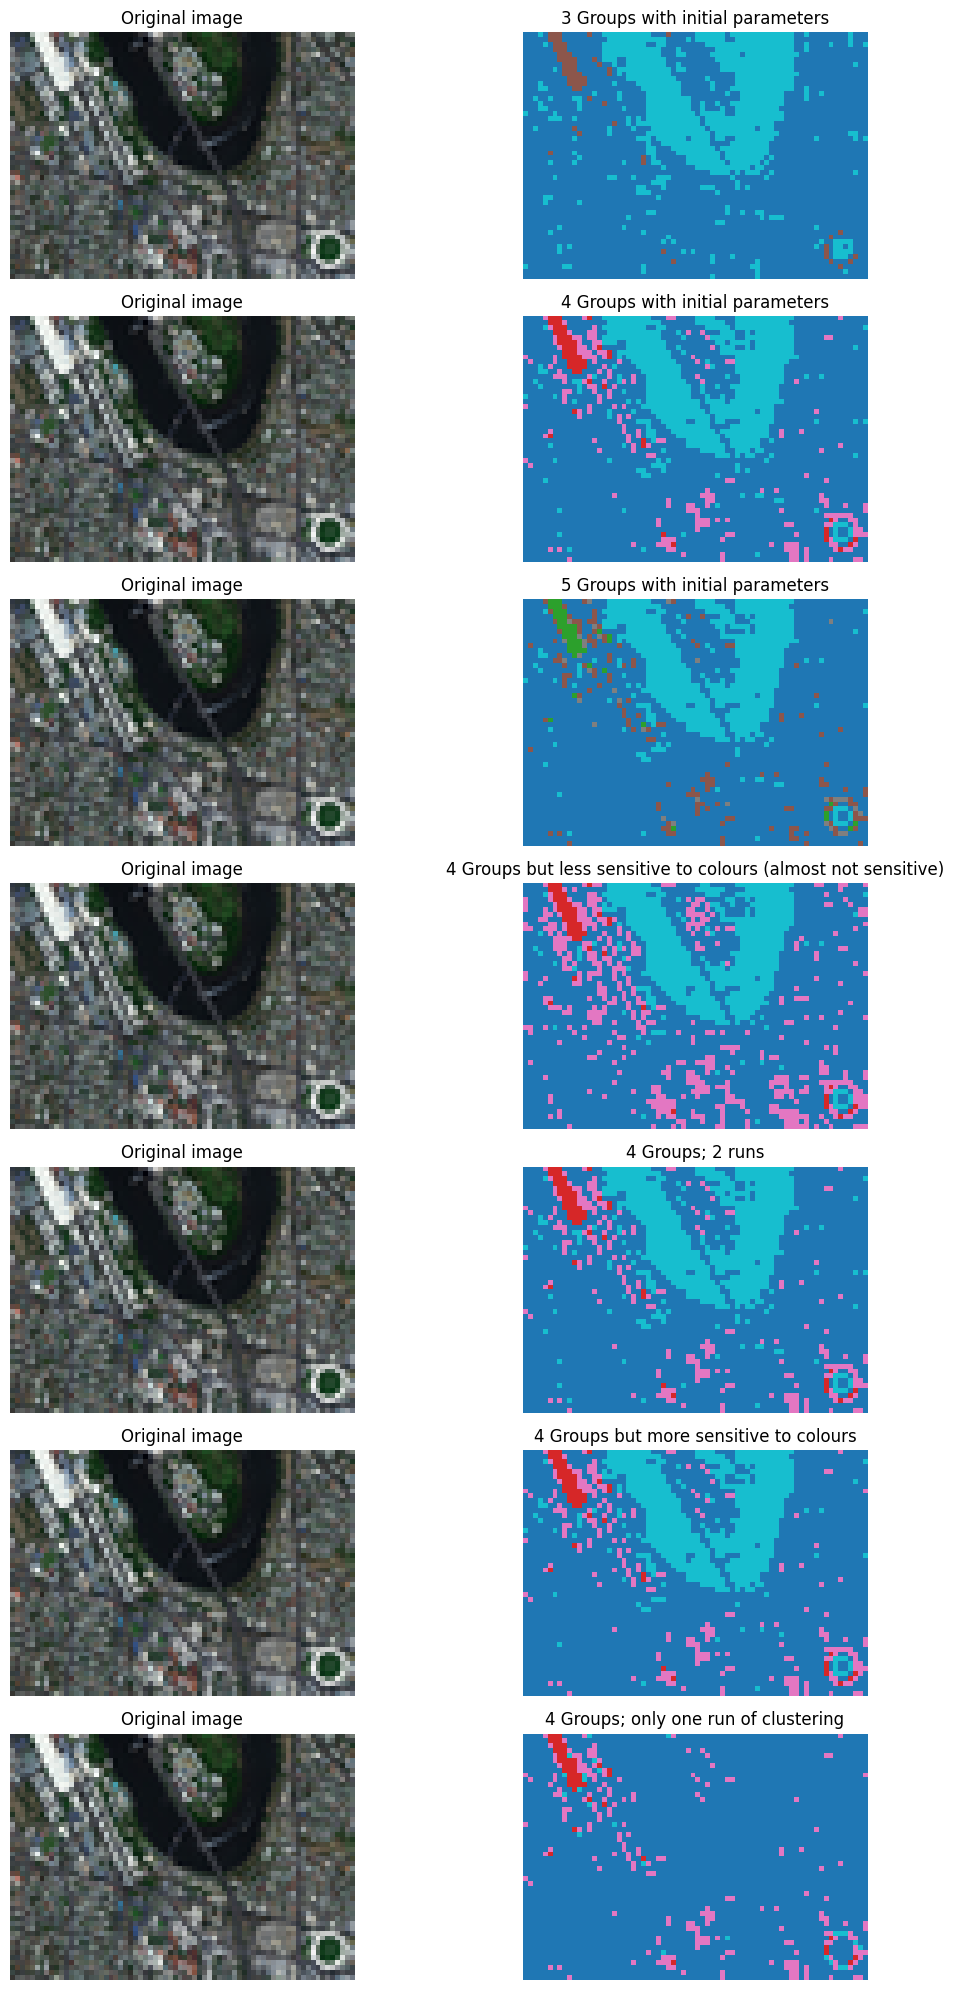

In [7]:
# now I want to show the comparisons of clustering with different parameters
# and show them on the graph

# list to put the results of experiments. First element of the list
# is the initial clustering from the previous task
label_images = [label_image]


# here I try to cluster pixels into 4 groups (not 3 like in previous exercise)
spectral = SpectralClustering(
    n_clusters=4,
    affinity='rbf',
    gamma=50,
    random_state=0,
    n_init=5 
)

labels_spectral = spectral.fit_predict(pixels)
label_image_1 = labels_spectral.reshape((H, W))
label_images.append(label_image_1)

# here I try to cluster pixels into 5 groups (not 3 like in previous exercise)
spectral = SpectralClustering(
    n_clusters=5,
    affinity='rbf',
    gamma=50,
    random_state=0,
    n_init=5 
)

labels_spectral = spectral.fit_predict(pixels)
label_image_2 = labels_spectral.reshape((H, W))
label_images.append(label_image_2)

# here I try to cluster pixels into 4 groups, but I make the clustering less sensitive to colours by setting gamma=1
spectral = SpectralClustering(
    n_clusters=4,
    affinity='rbf',
    gamma=1,
    random_state=0,
    n_init=5 
)

labels_spectral = spectral.fit_predict(pixels)
label_image_3 = labels_spectral.reshape((H, W))
label_images.append(label_image_3)

# here I try to cluster pixels into 4 groups, but only after 2 iteration, to check if we really need 5 iterations
spectral = SpectralClustering(
    n_clusters=4,
    affinity='rbf',
    gamma=50,
    random_state=0,
    n_init=2
)
labels_spectral = spectral.fit_predict(pixels)
label_image_4 = labels_spectral.reshape((H, W))
label_images.append(label_image_4)

# here I try to make the clustering even more sensitive to colours by setting gamma=100

spectral = SpectralClustering(
    n_clusters=4,
    affinity='rbf',
    gamma=100,
    random_state=0,
    n_init=5
)
labels_spectral = spectral.fit_predict(pixels)
label_image_5 = labels_spectral.reshape((H, W))
label_images.append(label_image_5)

# here I want to see if only 1 run is suitable for the task
spectral = SpectralClustering(
    n_clusters=4,
    affinity='rbf',
    gamma=50,
    random_state=0,
    n_init=1
)
labels_spectral = spectral.fit_predict(pixels)
label_image_6 = labels_spectral.reshape((H, W))
label_images.append(label_image_6)


# to create sub plots, as there are 6 experiments, the number of rows should be 7 as we also include initial for easier comparison
# 2 is because I want to have an original image near each experiment for better analysis
fig, axes = plt.subplots(7, 2, figsize=(12, 20))

# show the original image on the left side
axes[0, 0].imshow(satellite)
axes[0, 0].set_title("Original image")
axes[0, 0].axis("off")

# show the result of the experiment on the right side
axes[0, 1].imshow(label_images[0], cmap="tab10")
axes[0, 1].set_title("3 Groups with initial parameters")
axes[0, 1].axis("off")

# show the original image on the left side
axes[1, 0].imshow(satellite)
axes[1, 0].set_title("Original image")
axes[1, 0].axis("off")

# show the result of the experiment on the right side
axes[1, 1].imshow(label_images[1], cmap="tab10")
axes[1, 1].set_title("4 Groups with initial parameters")
axes[1, 1].axis("off")

# show the original image on the left side
axes[2, 0].imshow(satellite)
axes[2, 0].set_title("Original image")
axes[2, 0].axis("off")

# show the result of the experiment on the right side
axes[2, 1].imshow(label_images[2], cmap="tab10")
axes[2, 1].set_title("5 Groups with initial parameters")
axes[2, 1].axis("off")

# show the original image on the left side
axes[3, 0].imshow(satellite)
axes[3, 0].set_title("Original image")
axes[3, 0].axis("off")

# show the result of the experiment on the right side
axes[3, 1].imshow(label_images[3], cmap="tab10")
axes[3, 1].set_title("4 Groups but less sensitive to colours (almost not sensitive)")
axes[3, 1].axis("off")

# show the original image on the left side
axes[4, 0].imshow(satellite)
axes[4, 0].set_title("Original image")
axes[4, 0].axis("off")

# show the result of the experiment on the right side
axes[4, 1].imshow(label_images[4], cmap="tab10")
axes[4, 1].set_title("4 Groups; 2 runs")
axes[4, 1].axis("off")

# show the original image on the left side
axes[5, 0].imshow(satellite)
axes[5, 0].set_title("Original image")
axes[5, 0].axis("off")

# show the result of the experiment on the right side
axes[5, 1].imshow(label_images[5], cmap="tab10")
axes[5, 1].set_title("4 Groups but more sensitive to colours")
axes[5, 1].axis("off")

# show the result of the experiment on the right side
axes[6, 0].imshow(satellite)
axes[6, 0].set_title("Original image")
axes[6, 0].axis("off")

# show the result of the experiment on the right side
axes[6, 1].imshow(label_images[6], cmap="tab10")
axes[6, 1].set_title("4 Groups; only one run of clustering")
axes[6, 1].axis("off")

# to make the chart look better
plt.tight_layout()

# to show the chart
plt.show()









Our goal is to divide the picture into 4 groups: forest, water, urban area, and farmland. That is why it is better to set n_clusters=4 rather than n_clusters=3 because there are 4 groups. 

- So let's compare the first image (n_clusters=3) against the second picture (n_clusters=4): there are 3 different colours on the first picture and 4 different colours on the second. 
So on the first image, we only found 3 different groups. We need 4, that is why we'd better set n_clusters=4. And on the second picture, we clearly see 4 different colours 
meaning that we divided the picture into 4 different groups based on pixels.

- The third picture shows the division into 5 clusters based on pixels. For this task it seems a little too much because it starts to detect some additional small features like dark green but we still want to identify it like forest.

- The fourth picture shows the results when gamma is set to 1, which means that the clustering should be less sensitive to colours. And we can see more pink colours, which adds some noise.

- The 5th picture shows that there are less details but overall the clustering seems the same

- The picture 6 shows that larger gamma gives us less pink points indicating that gamma=100 is better than gamma=1. But for this task, I would keep gamma=50 as initially given.

- The last picture shows that we need a least 2 runs to make a good clustering. Because n_init=1 shows poor performance.

In conclusion, we can see that to get the general perception of clusters, we may not need 5 runs. Because in both, when we set n_init = 2 and n_init = 5, there is still noise, but n_init = 2 is less computationally expensive, that is why we can achieve similar result through 2 runs only. And another conclusion we can make is that 4 clusters is enough for this task.


---

# Part II - PCA and Robust PCA for Image Analysis (40 marks)

\
This part has two sections. In **Section A** we apply PCA via SVD to a set of handwritten
digit images to compute *eigendigits* and study low-rank reconstructions. In **Section B**
we implement **Robust PCA** to separate a corrupted image into a clean low-rank background
and a sparse corruption layer.

The digit images are **24×24** pixels each, stored flattened as vectors of length 576.

---

## Section A — Eigendigits via PCA (20 marks)

In [8]:
f = open('digits.npy', 'rb')
digits = np.load(f)
f.close()
nimages = len(digits)
print('Dataset shape:', digits.shape)

def vec2img(vec):
    return vec.reshape(24, 24)

Dataset shape: (1797, 24, 24)


Randomly select **1000** images from the dataset and work with these throughout Section A.
Store them in **<font color='red'>X_sample</font>**.

1. Compute **<font color='red'>mean_digit</font>** — the mean image (shape `(576,)`) of the 1000 samples.
2. Subtract the mean to get **<font color='red'>X_centered</font>** (shape `(1000, 576)`).
3. Compute the SVD of **X_centered** using `svd(..., full_matrices=False)`. Store the results
   in **<font color='red'>U</font>**, **<font color='red'>S_vals</font>**, **<font color='red'>Vt</font>**.
   The rows of **Vt** are the **eigendigits**.

**Important:** use `np.random.seed(0)` before sampling so results are reproducible.

In [9]:
### DO NOT REMOVE/EDIT THIS CELL ###

In [10]:
# Hint: select 1000 images with np.random.seed(0) and np.random.choice;
#        flatten each image with .reshape(1000, -1) to get shape (1000, 576)

# to fix that every time the sample will contain the same 1 000 digits
np.random.seed(0)
# randomly choose 1 000 digits; replace=False means that the images will not be repeated (all different indices)
# and .reshape(1_000, -1) means that we have 1 000 digits and 576 pixels (-1 puts remaining values)
# to make this test go through we need to set data type to float 64 (float32 is less precise). 
# dtype=float64 is better for statistical tests, because even though it consumes more memory than float16 or float32, float 64 is more precise
X_sample = digits[np.random.choice(len(digits), size=1_000, replace=False)].reshape(1_000, -1).astype(np.float64)


# Compute mean and center
# in X_sample we have 1 000 different images (rows) --> axis=0 means that we calculate the mean for each pixel
# to make this test go through we need to set data type to float 64 (float32 is less precise). 
# dtype=float64 is better for statistical tests, because even though it consumes more memory than float16 or float32, float 64 is more precise
mean_digit = np.mean(X_sample, axis=0, dtype=np.float64)
# as said, I deduct the mean value from the X_sample and get X_centered
X_centered = X_sample - mean_digit

# SVD — full_matrices=False is important for memory
# getting U - left singular vectors; S_vals = singular values; Vt - transposed right singular vectors
U, S_vals, Vt = svd(X_centered, full_matrices=False)

# Vt are the eigendigits (what patterns have been found)
# U shows how are located in terms of its components
# S_vals show the importance of each component
# U * S_vals gives the component scores for each image
# SVD helps us find some important patterns. We use X_centered because we want to analyse how different each image is from the average image


In [11]:
### DO NOT REMOVE/EDIT THIS CELL ###

assert mean_digit.shape == (576,)
assert X_centered.shape == (1000, 576)
assert_almost_equal(X_centered.mean(axis=0), np.zeros(576), decimal=10)
assert Vt.shape[1] == 576
print('--- TEST PASSED ---')

--- TEST PASSED ---


Display **mean_digit** and the **first 16 eigendigits** in a single row of 16 subplots.
Use `vec2img` to reshape each vector before displaying with `plt.imshow(..., cmap='gray')`.

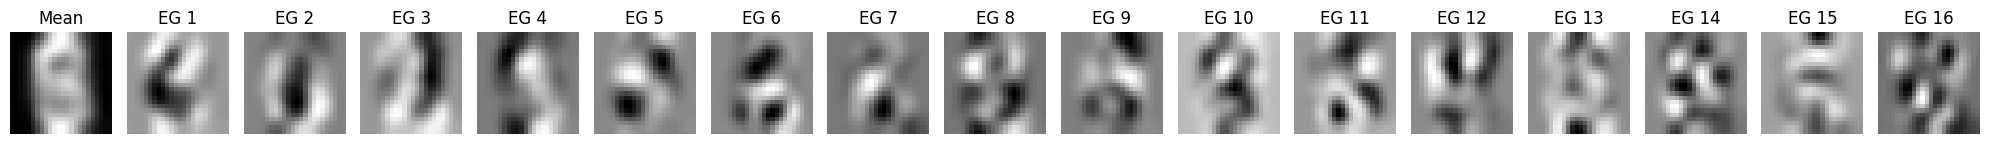

In [12]:
# as always: set 17 columns with 1 row 5 height; 20 width size
fig, axes = plt.subplots(1, 17, figsize=(20, 5))

# applying vec2img function to mean_digit and show it as the first picture
axes[0].imshow(vec2img(mean_digit), cmap='gray')
# set title
axes[0].set_title("Mean")
# no axis
axes[0].axis("off")

# go through the elements of Vts: want to get first 16: from 0 to 15 including
for i in range(16):
    # converting eigendigit to vector, starting from 1st index because of mean image, that is why i + 1
    axes[i + 1].imshow(vec2img(Vt[i]), cmap='gray')
    # title
    axes[i + 1].set_title(f"EG {i + 1}")
    # no axis
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()



In [13]:
### DO NOT REMOVE/EDIT THIS CELL ###

Reconstruct the **first image** in `X_sample` using k = 2, 5, 20, 50, 100 eigendigits.
For each k, compute the reconstruction as:
$$\hat{x} = \text{mean\_digit} + (x_{\text{centered}} \cdot V_k^\top) \cdot V_k$$
where $V_k$ contains the first k rows of **Vt**.

Display the original and the 5 reconstructions in a single row. Store the reconstruction
for k=50 in **<font color='red'>recon_50</font>**.

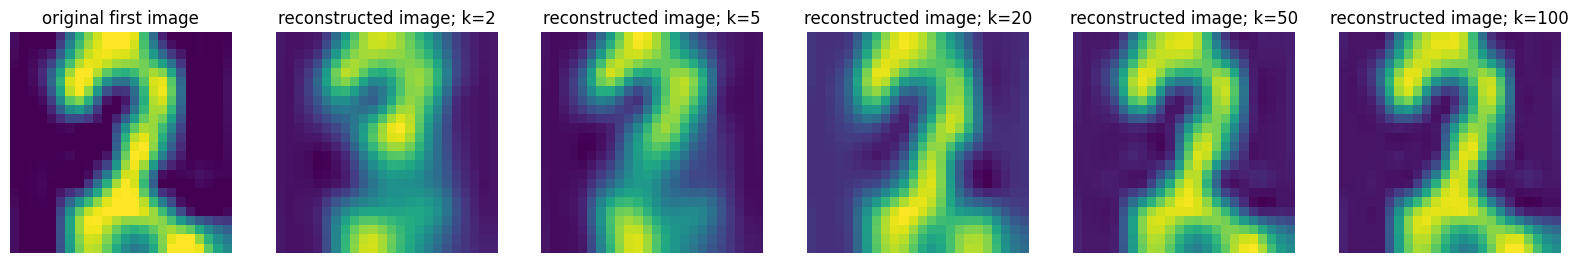

In [14]:
# identify numbers of eigendigits as asked in the task
k_list = [2, 5, 20, 50, 100]
# set an empty list, thus I will add here our reconstructions
reconstructed_imgs = []
# take the first image. index 0 means the first entry to X_sample --> first row of pixels is the first image
first_img = X_sample[0]

# iterate through each k
for k in k_list:
    # update image using first k eigendigits using formula provided
    # X_centered[0] also corresponds to the first image
    # taking the first k rows by  Vt[:k]
    x_updated = mean_digit + (X_centered[0] @ Vt[:k].T) @ Vt[:k]
    # add image to initially set list
    reconstructed_imgs.append(x_updated)

# k = 50 if the 4th elements in k_list --> index of the element is 3 --> 
# the list with reconstructed images has the same order as k_list 
# --> 4th element in the list with reconstructed images corresponds to k=50
recon_50 = reconstructed_imgs[3]

# setting subplots with 6 cols; 1 row
fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# show the original 1st image, and convert vector to image using the function above
axes[0].imshow(vec2img(first_img))
# title
axes[0].set_title("original first image")
# no axis
axes[0].axis("off")

# show result for each k
for i in range(len(reconstructed_imgs)):
    axes[i + 1].imshow(vec2img(reconstructed_imgs[i]))
    # as reconstructed_imgs has the same order as k_list we get k by k_list[i]
    axes[i + 1].set_title(f"reconstructed image; k={k_list[i]}")
    # no axis
    axes[i + 1].axis("off")

# so we can observe that the larger k, the more similar the picture is to the original one.
# When k=2 --> the picture barely reminds 2; and as k grows, the more the image reminds 2



In [15]:
### DO NOT REMOVE/EDIT THIS CELL ###

assert recon_50.shape == (576,)
print('--- TEST PASSED ---')

--- TEST PASSED ---


Plot the **cumulative explained variance** against the number of components (use all
singular values in `S_vals`). The explained variance ratio for component $i$ is
$s_i^2 / \sum_j s_j^2$.

Store the cumulative explained variance array in **<font color='red'>cum_var</font>**.
In the Markdown cell below state: how many eigendigits are needed to reach **85%** explained
variance?

Text(0.5, 1.0, 'Cumulative Explained Variance Against SVD Components')

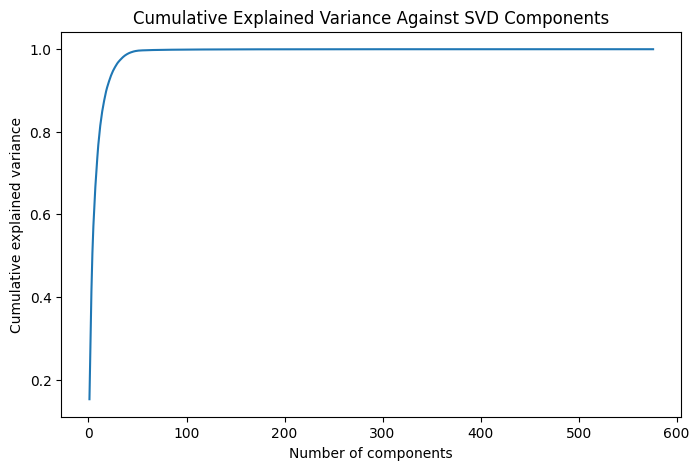

In [16]:
# use the formula given to calculate cum_var
cum_var = np.cumsum((S_vals ** 2) / np.sum(S_vals ** 2))
# arange an array with values from 1 to 576
components = np.arange(1, cum_var.shape[0] + 1)

# plot cumulative explained variance 
plt.figure(figsize=(8, 5))

# plot results
plt.plot(components, cum_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance Against SVD Components")









In [17]:
### DO NOT REMOVE/EDIT THIS CELL ###

assert len(cum_var) == len(S_vals)
assert_almost_equal(cum_var[-1], 1.0, decimal=5)
print('--- TEST PASSED ---')

--- TEST PASSED ---


In [18]:
print(cum_var)

[0.15226524 0.29043702 0.41336089 0.50578524 0.57143409 0.62028558
 0.66627124 0.70340792 0.73679413 0.76786707 0.79172287 0.81460334
 0.8323424  0.84918881 0.86283807 0.87572226 0.88711673 0.8982988
 0.9073854  0.91533847 0.92264927 0.92973354 0.93622859 0.9419583
 0.94743352 0.95205318 0.95635782 0.96042984 0.96423118 0.96770408
 0.97055861 0.97321713 0.97577163 0.97817413 0.98049799 0.98263871
 0.98444457 0.98607202 0.98758995 0.98896202 0.99015509 0.99122383
 0.99217182 0.99299978 0.99378977 0.99449293 0.9950868  0.99559653
 0.99599184 0.99635055 0.99662473 0.99683002 0.99699022 0.99712227
 0.99723261 0.99733167 0.99742629 0.99751423 0.99759748 0.99767531
 0.99775032 0.99782133 0.99788795 0.99794937 0.99800808 0.99806348
 0.99811498 0.99816601 0.99821495 0.99826232 0.99830829 0.99835284
 0.99839512 0.99843556 0.99847432 0.99851101 0.99854679 0.99858149
 0.99861486 0.99864676 0.9986785  0.99870906 0.99873832 0.99876659
 0.99879426 0.99882058 0.99884668 0.99887233 0.99889615 0.998919

In [19]:
n_85 = np.argmax(cum_var >= 0.85) + 1
print(n_85)

15


As we can see, we need 15 eigendigits to reach 85% explained variance. 
15th eigendigit has explained variance of ~ 86.28%; 14th eigendigit has explained variance of ~ 84.92 %

---

## Section B — Robust PCA via IALM (20 marks)

\
We now implement **Robust PCA** to decomposessss a corrupted image $M = L + S$ into a
**low-rank component** $L$ and a **sparse corruption** $S$, by solving:
$$\min_{L,S}\; \|L\|_* + \lambda\|S\|_1 \quad\text{s.t.}\quad L+S=M.$$

We use the **Inexact Augmented Lagrangian Method (IALM)**:
$$\begin{aligned}
L^{(k+1)} &= \mathcal{D}_{1/\mu}(M - S^{(k)} + Y^{(k)}/\mu),\\
S^{(k+1)} &= \mathcal{T}_{\lambda/\mu}(M - L^{(k+1)} + Y^{(k)}/\mu),\\
Y^{(k+1)} &= Y^{(k)} + \mu(M - L^{(k+1)} - S^{(k+1)}),\\
\mu^{(k+1)} &= \min(\rho\,\mu^{(k)},\;\mu_{\max}),
\end{aligned}$$
where $\mathcal{D}_\tau$ soft-thresholds singular values and
$\mathcal{T}_\epsilon(x) = \text{sign}(x)\max(|x|-\epsilon,0)$ is element-wise soft-thresholding.

Stop when $\|M - L^{(k)} - S^{(k)}\|_F / \|M\|_F \le \text{tolerance}$.

The penalty parameter is initialized following Lin et al. (2010):
$$\mu_0 = 1.25 \;/\; \|M\|_2,$$
where $\|M\|_2$ is the spectral norm (largest singular value of $M$).
This ties the initial SVT threshold directly to the scale of the data,
ensuring the low-rank and sparse components are separated correctly from
the very first iteration.

**Step 1: Implement the two thresholding operators.**

- **<font color='red'>singular_value_threshold(A, tau)</font>** — compute SVD of A,
  soft-threshold singular values by tau, return reconstructed matrix.
- **<font color='red'>element_threshold(A, eps)</font>** — element-wise soft-threshold:
  $\text{sign}(A)\max(|A|-\varepsilon,\,0)$.

In [20]:
def singular_value_threshold(A, tau):
    
    """
    This function is designed to compute soft-thresholding to a matrix. 
    Used in Robust PCA to get low-rank component.
    Here we remove weak components, and we keep only strong
    
    Args:
        A: np.ndarray - Input matrix
        tau: float - threshold
    
    
    Returns:
        np.ndarray:  reconstructed matrix after SVD
    """
    
    # I calculate the svd for the given matrix, full_matrix=False assures not much memory used
    U, S_vals, Vt = svd(A, full_matrices=False)
    # apply thresholding to singular values --> 
    # for negative values, the function will give 0, 
    # for positive the singular value will be given
    S_vals_updated = np.maximum(S_vals - tau, 0)
    # make it a matrix. So we have singular values on the diagonal, and all other elements are 0s
    S_val_matrix = np.diag(S_vals_updated)
    # return the reconstructed matrix: low rank approximation
    return U @ S_val_matrix @ Vt

def element_threshold(A, eps):
    """
    Apply element-wise soft-thresholding to a matrix.

    Elements where absolute value is smaller than or equal to eps are set to zero,
    while larger elements stay the same.

    It is used in Robust PCA to obtain the sparse corruption component (some anomalies). 

    Args:

        A : np.ndarray
            Input matrix.
        eps : float
            Threshold value applied to each element.

    Returns:

        np.ndarray
            Matrix after element-wise soft-thresholding.
    """
    # np.sign gives matrix of values of either 1 or -1 depending on the sign of the element.
    # np.maximum chooses the max value
    # np.abs gives the absolute value of each element of A
    # then we calculate the difference between absolute values of A and eps
    # the we get the max value,
    # finally we keep the initial sign for non-zero values
    return np.sign(A) * np.maximum(np.abs(A) - eps, 0)




In [21]:
### DO NOT REMOVE/EDIT THIS CELL ###

# element_threshold
assert_almost_equal(element_threshold(np.array([[0.3,-0.2],[1.0,-1.5]]),0.5),
                    np.array([[0.0,0.0],[0.5,-1.0]]))
# singular_value_threshold: rank should not increase
B = np.outer([1.0,2.0,3.0],[1.0,0.5])  # rank-1
D = singular_value_threshold(B, 0.1)
assert D.shape == B.shape
# large tau => zero matrix
assert_almost_equal(singular_value_threshold(np.eye(3)*0.1, 1.0), np.zeros((3,3)))
print('--- TEST PASSED ---')

--- TEST PASSED ---


**Step 2: Implement the IALM Robust PCA solver.**

Write **<font color='red'>robust_pca(M, lam, mu, rho, mu_max, tolerance, max_iter, iter_print)</font>**
with defaults:
- `lam = None` → $1/\sqrt{\max(D,N)}$
- `mu = None`  → $1.25 \;/\; \|M\|_2$ &nbsp; (use `svd(M, compute_uv=False)[0]` for $\|M\|_2$)
- `mu_max = None` → $10^7 \times \mu_0$
- `rho = 1.5`, `tolerance = 1e-5`, `max_iter = 500`, `iter_print = 50`

Return **(L, S)**.

In [22]:
def robust_pca(
        M, lam=None, mu=None, rho=1.5, mu_max=None, 
        tolerance=1e-5, max_iter=500, iter_print=50
    ):
    
    """
    The function decomposes the initial matrix M as the sum of 2 matrices:
    L is something stable (e.g., when we have many images they all have the same background)
    S is something that is changing (some noise), some anomalies detected in M

    Returns:
        np.ndarray: 
            L is the normal part of the M
        np.ndarray:
            S is the corrupted part of the M
    """
    
    # singular_value_threshold for L
    # element_threshold for S
    
    # initialise the variables L, S, Y (based on the formula above)
    # L - normal part
    L = np.zeros((M.shape[0], M.shape[1]))
    # S - corrupted part
    S = np.zeros((M.shape[0], M.shape[1]))
    Y = np.zeros((M.shape[0], M.shape[1]))
    
    # only if lambda is not given, we need to use the formula given
    if lam is None:
        # the formula given
        lam = 1 / np.sqrt(np.maximum(M.shape[0], M.shape[1]))
    
    # getting the largest singular value
    # compute_uv=False means that we do not need left/right singular vectors
    # returns singular values in a descending order ---> 
    # the first element corresponds to the largest singular value
    M2 = svd(M, compute_uv=False)[0]
    # only if mu is not given, we need to use the formula given
    if mu is None:
        # the formula given
        mu = 1.25 / M2
    # only if mu_max is not given, we need to use the formula given
    if mu_max is None:
        # the formula given
        mu_max = (10 ** 7) * mu
        
    # initialise the current iteration: start from 1
    current_iter = 1
    # updating L, S, Y, mu till all iterations (500 times in this case)
    while current_iter <= max_iter:
        # modular division should be zero. so in this case, every 50 iterations we show the progress
        if current_iter % iter_print == 0:
            # print the current error (every iter_print iterations)
            print(f"There have been {current_iter} iterations; current error: {error}")
        # using the formula given above to update L
        L = singular_value_threshold(M - S + Y / mu, 1 / mu)
        # using the formula given above to update S
        S = element_threshold(M - L + Y / mu, lam / mu)
        # using the formula given above to update Y
        Y = Y + mu * (M - L - S)
        # using the formula given above to update the error
        error = norm(M - L - S) / norm(M)
        # if the error below the threshold, we stop
        if error <= tolerance:
            break
        # using the formula given above to update mu
        mu = np.minimum(rho * mu, mu_max)
        # update the current iteration number
        current_iter += 1
        
    # return L, S as asked
    return L, S
    
    
    
    
    
    



The cell below tests your robust_pca implementation on a small synthetic matrix of size 20 × 25. It constructs a rank-2 ground-truth low-rank component L and a sparse corruption S with 10% non-zero entries set to ±5, then checks that your decomposition recovers L+S=M with relative error below 1%. Complete the code. 

In [23]:
### DO NOT REMOVE/EDIT THIS CELL ###

np.random.seed(123)
D_r, N_r = 20, 25
U_r = np.random.randn(D_r, 2); V_r = np.random.randn(2, N_r)
L_true = U_r @ V_r
S_true = np.zeros((D_r, N_r))
idx_c = np.random.choice(D_r*N_r, size=int(0.10*D_r*N_r), replace=False)
S_true.flat[idx_c] = np.random.choice([-5.0, 5.0], size=len(idx_c))
### Fill in two lines of code here to define your robust PCA ###

# building M matrix based on true values
M_t = L_true + S_true
# applying my function
L_r, S_r = robust_pca(M_t)

rel_err = norm(M_t - L_r - S_r, 'fro') / norm(M_t, 'fro')
assert rel_err < 0.01, f'Error too large: {rel_err:.4f}'
print(f'Relative error: {rel_err:.6f}')
print('--- TEST PASSED ---')

Relative error: 0.000009
--- TEST PASSED ---


**Step 3: Denoise a corrupted image.**

Load the astronaut image, convert to grayscale, and corrupt **25%** of pixels by setting
them to 0 or 1 at random. Store the corrupted image in
**<font color='red'>corrupted_gray</font>**.

Apply `robust_pca` (tolerance=1e-4, max_iter=150) and clip the recovered L to [0,1].
Store in **<font color='red'>L_recovered</font>**.

Plot original, corrupted, and recovered side by side.

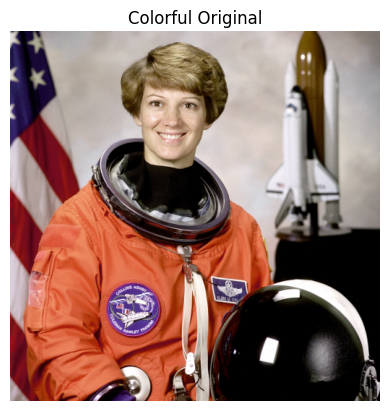

In [24]:
# Load and plot the original colorful image 
astro_color = img_as_float(data.astronaut())


# Plot the colorful
plt.imshow(astro_color)
plt.axis('off')
plt.title('Colorful Original')
plt.show()



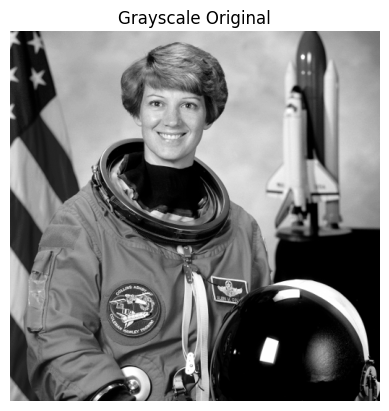

In [25]:
# Convert to grayscale and plot the image
astro_gray  = rgb2gray(astro_color)   # shape (512, 512)

# Plot the grayscale
plt.imshow(astro_gray, cmap='gray')
plt.axis('off')
plt.title('Grayscale Original')
plt.show()

In [26]:
# Corrupt 25% of pixels
# get the shape --> 512, 512
H, W = astro_gray.shape
# number of pixels
n_pixels = H * W
# 25% of pixels should be corrupted
n_corrupted_pixels = int(n_pixels * 0.25)
# rehshape it into 1D array
one_dim_astro_gray = astro_gray.flatten()
# make sure randomly generated indices will always be the same
np.random.seed(0)
# randomly choose 25% indices of all pixels.
# replace=False makes sure that all indices will be unique
random_indices = np.random.choice(a=n_pixels, size=n_corrupted_pixels, replace=False)
# replace pixels values by a randomly chosen pixel (0 or 1). Corrupt it
one_dim_astro_gray[random_indices] = np.random.randint(0, 2, size=n_corrupted_pixels)
# reshape the array, so we have a corrupted image in a general representation
corrupted_gray = one_dim_astro_gray.reshape((H, W))




In [27]:
# Apply Robust PCA
# applying the function with the parameters asked
L_recovered, S = robust_pca(corrupted_gray, tolerance=1e-4, max_iter=150)
# clip the image as aked
L_recovered = np.clip(L_recovered, 0, 1)


Text(0.5, 1.0, 'Recovered image')

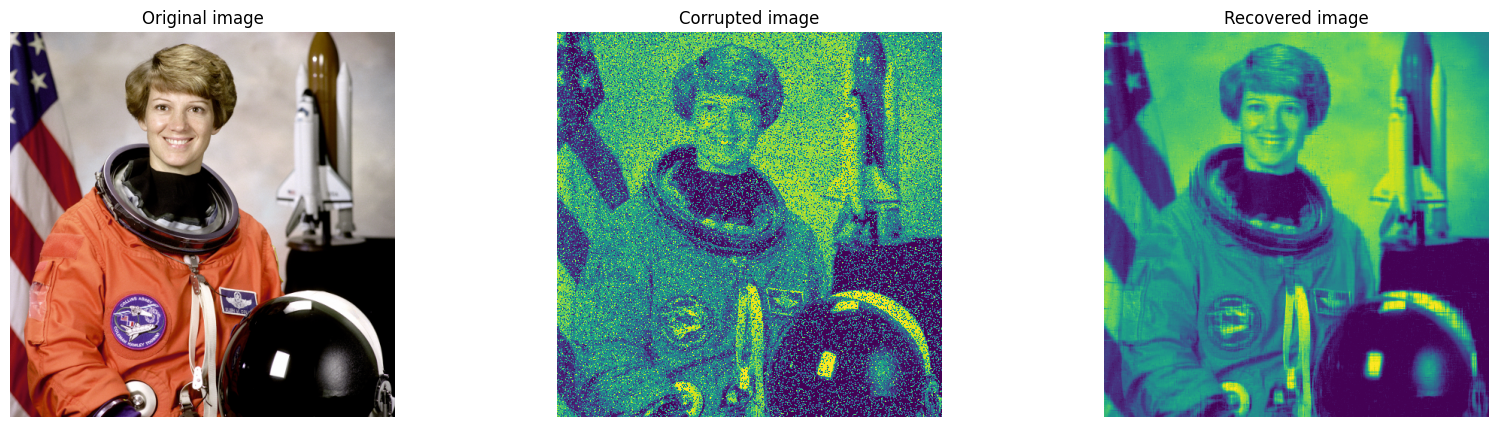

In [28]:
# setting 3 different columns for the plotting with size 20, 5
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# plot the original image defined above
axes[0].imshow(astro_color)
# no axis
axes[0].axis("off")
# put the title
axes[0].set_title("Original image")

# plot the corrupted image defined above
axes[1].imshow(corrupted_gray)
# no axis
axes[1].axis("off")
# put the title to say that it is a corrupted image
axes[1].set_title("Corrupted image")

# plot the recovered image using the robust PCA (noise separated)
axes[2].imshow(L_recovered)
# no axis
axes[2].axis("off")
# put the title to say that it is a recovered image
axes[2].set_title("Recovered image")



In [29]:
### DO NOT REMOVE/EDIT THIS CELL ###

In the Markdown cell below answer:
1. What does the low-rank component $L$ represent, and what does sparse component $S$ represent?
2. How does Robust PCA differ from standard PCA when outliers are present?
3. What happens qualitatively if $\lambda$ is set much larger or much smaller?

1. L represents the clean matrix with minimised amount of noise (it is hard to completely remove the noise, thus I say minimised)
    S represents the noise detected: any corruptions, outliers or anomalies in the matrix. There are pixels that differ strongly from the low-rank structure, they are put in sparse matrix (S)
    M = L + S is the initial matrix with outliers and noise

2. If there are many outiers/anomalies/ corruptions in data, Standard PCA may include them as components, and thus it becomes worse. Because standard PCA may include these outliers as principal components. While Robust PCA separates corrupted data and clean data, so it provides low-rank approximation for the clean data.

3. When lambda is too large, the will be less noise recorded (almost no noise) because it becomes expensive to put something in the sparse matrix (S). While when lambda is too small, there will be much noise, because it becomes cheaper to put more entries into the sparse matrix (the elements that are not noise may be put in the sparse matrix). Mathematically, the larger lambda, the less number of non-zero elements will have our sparse matrix



---

# Part III - Autoencoder for Dimensionality Reduction (30 marks)

\
We implement a **shallow autoencoder** from scratch using only NumPy and apply it to
compress and reconstruct handwritten digit images.

The network has the structure:
$$z = \sigma(W_1 x + b_1), \qquad \hat{x} = W_2 z + b_2,$$
where $\sigma$ is the **sigmoid** activation applied element-wise and the output layer is
**linear**. Parameters: $W_1\in\mathbb{R}^{p\times d}$, $b_1\in\mathbb{R}^p$,
$W_2\in\mathbb{R}^{d\times p}$, $b_2\in\mathbb{R}^d$.

Loss: $\mathcal{L}=\frac{1}{n}\|{\hat{X}}-X\|_F^2$. Optimized via **mini-batch gradient descent**.

---

In [30]:
f = open('digits.npy','rb')
digits_all = np.load(f); f.close()
N_train = 500
X_train = digits_all[:N_train].astype(float).reshape(N_train, -1) 
print('Training data shape:', X_train.shape)

Training data shape: (500, 576)


**Step 1: Sigmoid and its derivative.**

- **<font color='red'>sigmoid(z)</font>** — element-wise $1/(1+e^{-z})$.
- **<font color='red'>sigmoid_deriv(z)</font>** — element-wise $\sigma(z)(1-\sigma(z))$.

In [31]:
def sigmoid(z):
    
    """
    Calculates the sigmoid function.

    Args:
        z (float or np.ndarray): input value or array of values

    Returns:
        float or np.ndarray: sigmoid value(s)
    """
    
    # just the formula above np.exp(-z) is e to the power of -z
    return 1 / (1 + np.exp(-z))
    
def sigmoid_deriv(z):
    
    """
    Calculates the derivative of the sigmoid function.

    Args:
        z (float or np.ndarray): input value or array of values

    Returns:
        float or np.ndarray: derivative of sigmoid at z
    """
    
    # formula given above using the function above
    return sigmoid(z) * (1 - sigmoid(z))
    
    
    
    
    
    

In [32]:
### DO NOT REMOVE/EDIT THIS CELL ###

z_t = np.array([-2.0, 0.0, 2.0])
assert_almost_equal(sigmoid(z_t), [0.11920292, 0.5, 0.88079708], decimal=6)
assert_almost_equal(sigmoid_deriv(z_t), sigmoid(z_t)*(1-sigmoid(z_t)), decimal=10)
assert_almost_equal(sigmoid_deriv(np.array([0.0])), [0.25], decimal=8)
print('--- TEST PASSED ---')

--- TEST PASSED ---


\
**Step 2: Forward pass.**

**<font color='red'>forward(X, W1, b1, W2, b2)</font>** — takes input batch `(n, d)` and returns
**(z, x_hat)**:
- $z = \sigma(X W_1^\top + b_1)$, shape `(n, p)`.
- $\hat{x} = z W_2^\top + b_2$, shape `(n, d)`.

In [33]:
def forward(X, W1, b1, W2, b2):
    
    """
    The function calculates encoder and decoder

    Returns:
        ndarray: encoder
        ndarray: decoder
    """
    
    # encoder: as stated in formula above, sigmoid function at  X @ W1.T + b1
    # W1.T - transposed W1; @ - the way to multiply matrices
    # compress data
    z = sigmoid(
        X @ W1.T + b1
    )
    
    # decoder: formula above
    # W2.T - transposed W2; @ - the way to multiply matrices
    # reconstructed data
    x_hat = z @ W2.T + b2
    
    # return encoder and decoder
    return z, x_hat








In [34]:
### DO NOT REMOVE/EDIT THIS CELL ###

np.random.seed(1)
d_t,p_t,n_t = 576,32,10
W1_t=np.random.randn(p_t,d_t)*0.01; b1_t=np.zeros(p_t)
W2_t=np.random.randn(d_t,p_t)*0.01; b2_t=np.zeros(d_t)
X_t=np.random.rand(n_t,d_t)
z_t,xh_t=forward(X_t,W1_t,b1_t,W2_t,b2_t)
assert z_t.shape==(n_t,p_t) and xh_t.shape==(n_t,d_t)
assert z_t.min()>0 and z_t.max()<1
print('--- TEST PASSED ---')

--- TEST PASSED ---


\
**Step 3: Backward pass.**

**<font color='red'>backward(X, z, x_hat, W1, b1, W2, b2)</font>** — returns gradients
**(dW1, db1, dW2, db2)** of $\mathcal{L}=\frac{1}{n}\|\hat{X}-X\|_F^2$.

*Hint: start from the output layer error $\delta_2 = \frac{2}{n}(\hat{X}-X)$, then
backpropagate through $W_2$, through the sigmoid, and through $W_1$.*

In [35]:
def backward(X, z, x_hat, W1, b1, W2, b2):
    
    """
    The aim of the function is to calculate the gradients of the Loss function

    Returns:
        np.ndarray: dW1,
        np.ndarray: db1,
        np.ndarray: dW2,
        np.ndarray: db2
    """
    
    n = X.shape[0]

    # output layer error; derivative of L in terms of X_hat
    delta_2 = (2 / n) * (x_hat - X)
    
    # dL / dW2 = dL / dx_hat * dX_hat / dW2 = delta_2 * dX_hat / dW2
    # now let's look at X_hat = z * W2.T + b2
    # dW2 must have the same shape as W2. Let's estimate the shape of W2
    # from the task we know that X_hat has shape of (n, d); z has shape of (n, p)
    # the multiplication makes sense only when W2.T has the shape of (p, d) --> because z*W2.T has the shape of (n, d): it is just a matrix multiplication definition;
    # b2 also has the shape of (d, ) 
    # --> as given X_hat has the shape of (n, d)
    # now we know and proved that W2.T has the shape of (p, d) ----> W2 has the shape of (d, p): just definition of a transposed matrix
    # ---> the shape of dX_hat / dW2 has the shape as W2: (d, p)
    # again delta_2 must have d columns thus the multiplication will make sense
    # now delta2 has the shape of (n, d), and for the multiplication to makes sense as we multiply by z which has the shape of (n, p),
    # we have to transpose delta_2 such that it will have the shape of (d, n), then the multiplication will make sense
    # finally the result of multiplication will have the shape of (d, p) exactly like the shape of W2.
    dW2 = delta_2.T @ z
    # db2 must have the same shape as b2 --> b2 has the shape of (1, d) while delta2 has the shape of (n, d); 
    # dL / db2 = dL / dx_hat * dX_hat / db2 = delta_2 --> we need to sum up each row
    db2 = np.sum(delta_2, axis=0)
    
    # dL / dW1 = dL / dX_hat * dX_hat / dz * dz / da * da / dW1
    # a is an input to the sigmoid function
    # Here z is already sigmoid(a), so sigmoid'(a) = z * (1 - z)
    delta_1 = (delta_2 @ W2) * z * (1 - z)

    # the same logic as above but we give X because the input for the sigmoid function is X @ W1.T + b1 --> d / dW1 = X
    dW1 = delta_1.T @ X
    db1 = np.sum(delta_1, axis=0)
    
    # return all values
    return dW1, db1, dW2, db2
    
    
    
    




**Step 4: Training loop.**

**<font color='red'>train_autoencoder(X, p, lr, n_epochs, batch_size, random_state)</font>**:
- `lr=0.01`, `n_epochs=50`, `batch_size=128`, `random_state=0`
- Initialize weights: Gaussian std=0.01, biases=0.
- Return **(W1, b1, W2, b2, loss_history)**.

After training: plot the loss curve and display **5 original vs 5 reconstructed** digit images
side by side.

In [36]:
def train_autoencoder(X, p, lr=0.01, n_epochs=50, batch_size=128, random_state=0):
    
    """
    The purpose of this function is to use stochastic gradient descent, 
    and return the parameters which minimise the error function along with loss history

    Returns:
        np.ndarray: W1,
        np.ndarray: b1,
        np.ndarray: W2,
        np.ndarray: b2,
        list: loss_history
    """
    
    # to make all random choices stable all the time when we re-run the notebook
    rng = np.random.default_rng(random_state)
    
    # to store loss results here
    loss_history = []
    
    # get n, d because based on the task description, X has n rows and d cols
    n, d = X.shape
    
    # generate a matrix with p rows; d cols as said in the task, and fill the matrix with random values that are normally distributed with mean (loc): 0 and std (scale): 0.01
    # W1 are initial weights, they have to be randomly chosen, and then updated via back prop method, but we always start with random
    W1 = rng.normal(loc=0, scale=0.01, size=(p, d))
    
    # shape of b1 is p as given above, and we start from 0 bias as stated above
    b1 = np.zeros(shape=(p))
    
    # generate a matrix with d rows; p cols as said in the task, and fill the matrix with random values that are normally distributed with mean (loc): 0 and std (scale): 0.01
    # W2 are initial weights, they have to be randomly chosen, and then updated via back prop method, but we always start with random
    W2 = rng.normal(loc=0, scale=0.01, size=(d, p))
    
    # shape of b2 is d as given above, and we start from 0 bias as stated above
    b2 = np.zeros(shape=(d))
    
    # one epoch is when we went through the whole dataset one
    # n_epoch means that we have n_epoch times iterate through the whole dataset
    for epoch in range(n_epochs):
        # to shuffle the input data, randomly choosing indices with the size of X
        random_indices = rng.permutation(n)
        # shuffled data
        X_shuffled = X[random_indices]
        # initialise the loss on each epoch to further update it
        epoch_loss = 0
        # initialise how many data we processed
        n_seen = 0
        # so we need to go through the whole dataset by taking batches of the given size
        # for the default batch_size, we'll have 0:128; 128:256, and so on
        for start in range(0, n, batch_size):
            # take the batch
            interim_x = X_shuffled[start:start + batch_size]
            # use forward propagation function to get the encoder (z) and decoder (x_hat)
            # getting predictions based on the current weights
            z, x_hat = forward(X=interim_x, W1=W1, b1=b1, W2=W2, b2=b2)
            
            # batch size
            batch_n = interim_x.shape[0]
            # calculating the loss function for this batch
            batch_loss = np.sum((x_hat - interim_x) ** 2) / batch_n
            
            # getting gradients
            dW1, db1, dW2, db2 = backward(X=interim_x, z=z, x_hat=x_hat, W1=W1, b1=b1, W2=W2, b2=b2)

            # gradient descent method, updating weights and biases. Just a gradient descent method, as we are minimising the cost function, 
            # so we need to subtract the gradient multiplied by learning rate
            # gradient shows how our loss function changes after updating weights
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
            
            # updating loss function
            epoch_loss += batch_loss * batch_n
            
            # record how many data records we processed
            n_seen += batch_n

        # calculating loss for one particular epoch
        epoch_loss = epoch_loss / n_seen
        # updating the list with loss function history
        loss_history.append(epoch_loss)
        # just to see how loss function changes on each epoch
        # print(f"Finished epoch {epoch}. Current loss is {epoch_loss}")

    # return the optimised parameters along with history of loss functions
    return W1, b1, W2, b2, loss_history
            
    
    
    








In [37]:
### DO NOT REMOVE/EDIT THIS CELL ###

**Step 5: Compare with PCA.**

Using SVD on `X_train`, compute PCA reconstructions with **p = 32** components
(same bottleneck as the autoencoder). Display original, PCA reconstruction, and autoencoder
reconstruction for the same 5 images in three rows.

In the Markdown cell below answer:
1. Which method gives better visual reconstructions? Does this match your expectation?
2. What objective function difference explains the quality gap?
3. A **linear autoencoder** (identity activation instead of sigmoid) is mathematically
   equivalent to which method, and why?

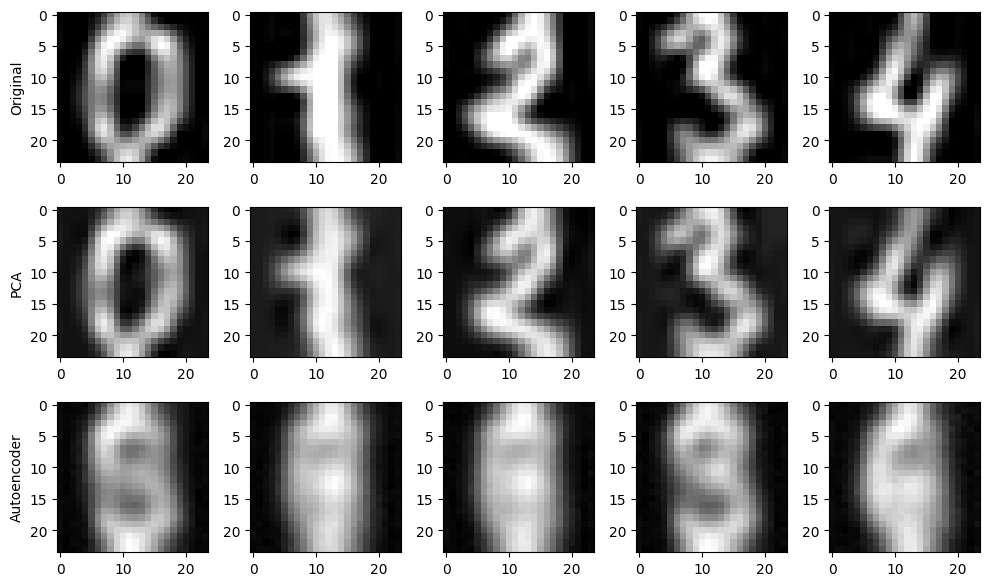

In [38]:
# PCA
# components
p = 32
# mean value for each row of X_train, basically we get the average for each pixel of the image
mean = np.mean(X_train, axis=0)
# as in PCA method we subtract the mean value from the original image
X_centered = X_train - mean
# getting svd based on the centered image; full_matrices=False because of memory optimisation
U, S_val, Vt = svd(X_centered, full_matrices=False)
# take first p components
Vt_updated = Vt[:p]
# update the image
X_train_pca_centered = X_centered @ Vt_updated.T @ Vt_updated
# get the image reconstructed by adding an average value of each pixel to it
X_train_pca_recon = X_train_pca_centered + mean

# Autoencoder
# get parameters for autoencoder with the loss history; as said in the task p should be 32
W1, b1, W2, b2, loss_history = train_autoencoder(X=X_train, p=32)
# get encoder and decoder
z, X_train_aut_recon = forward(X=X_train, W1=W1, b1=b1, W2=W2, b2=b2)
# just a sample of 5 digits, can be any other
idx = [0, 1, 2, 3, 4]
# get the image size: X_train.shape[1] is the number of features; as the image should have a square shape, height should be equal to width
# in this case we have X_train.shape[1]=576, to make the image squared it should be 24 x 24
img_size = int(np.sqrt(X_train.shape[1]))

# plot it; 3 rows, 5 cols
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

# iterate through all indices; enumerate that we'll have: j=0 and i=0, j=1 and i=1 and so on so far
for j, i in enumerate(idx):
    # just as always show the ith image, reshape it, otherwise it will be an error
    axes[0, j].imshow(X_train[i].reshape(img_size, img_size), cmap="gray")
    axes[1, j].imshow(X_train_pca_recon[i].reshape(img_size, img_size), cmap="gray")
    axes[2, j].imshow(X_train_aut_recon[i].reshape(img_size, img_size), cmap="gray")

# set corresponding titles
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("PCA")
axes[2, 0].set_ylabel("Autoencoder")

# make it look better
plt.tight_layout()
# show the plot
plt.show()




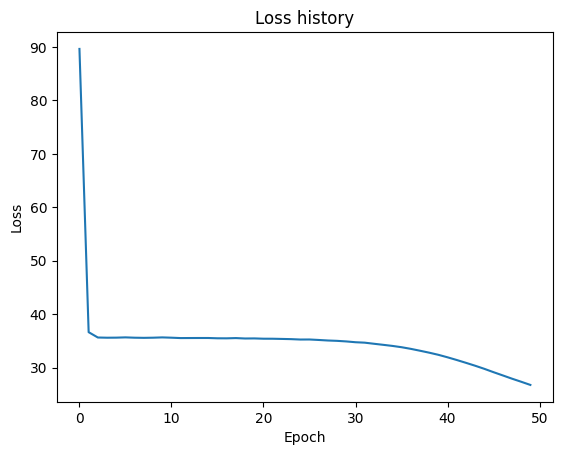

In [39]:
# plot the loss history, to see how the loss function was changing on each epoch
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss history")
plt.show()


In [40]:
### DO NOT REMOVE/EDIT THIS CELL ###

1. Which method gives better visual reconstructions? Does this match your expectation?


PCA gives the best results based on the picture above, even though the images look a bit more blur, the digits can be easily interpreted.

No, I did not expect to see the PCA performing better than autoencoder. I expected an autoencoder with a sigmoid activation function can reconstruct the images better, as it can model non-linear relationships in data.


2. What objective function difference explains the quality gap?

They both aim to minimise the reconstruction error function. PCA finds the optimal linear subset with p=32 size for centered data. SVD gives the best optimal solution for linear reconstruction PCA.

Autoencoder also minimises the reconstruction loss. But it does it via parameters (W; b) of neural network which are found using gradient descent method. Autoencoder uses non-linear sigmoid activation function, that is why the model could be over-trained or under-trained. That is why PCA can look better in this task.



3. A **linear autoencoder** (identity activation instead of sigmoid) is mathematically
   equivalent to which method, and why?

It becomes mathematically identical to PCA method. Because if we change the sigmoid activation function to an identity activation, then the autoencoder becomes linear. Thus, the model compresses p components and then linearly reconstructs to the initial shape. 



